# ❤️ Heart Disease Prediction: End-to-End Pipeline
**Author:** Arpana kumari

**Objective:** To build a supervised machine learning pipeline that predicts the risk of heart disease based on clinical patient data. 

This notebook covers data ingestion, exploratory data analysis (EDA), data cleaning (mean imputation for hidden missing values), feature engineering, model training across multiple algorithms, and serialization of the best-performing model for web deployment.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import joblib

warnings.filterwarnings("ignore")

## 1. Data Loading and Initial Inspection
First, we load the dataset and inspect its structure, data types, and basic statistical summaries. This helps us identify potential missing values or anomalies (like minimum values of 0 where they shouldn't exist).

In [2]:
# Load the dataset
df = pd.read_csv("heart.csv")

In [3]:
# EDA
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
# Display basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Display statistical summary
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: xlabel='HeartDisease'>

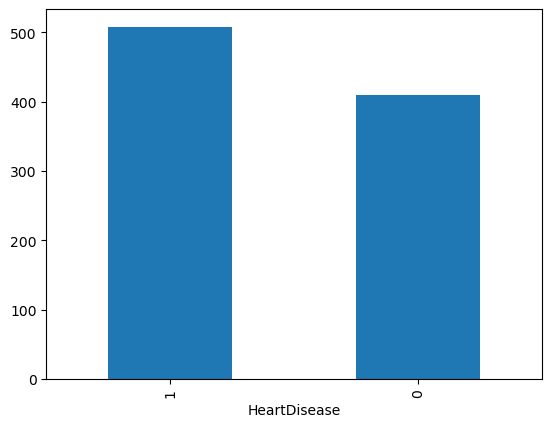

In [8]:
df["HeartDisease"].value_counts().plot(kind = "bar")

In [9]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## 2. Exploratory Data Analysis (EDA) & Identifying Anomalies
We visualize the distributions of our numerical features. Upon inspecting the statistical summary and the histograms, we can observe that `Cholesterol` and `RestingBP` have minimum values of 0. In a medical context, a resting blood pressure or cholesterol level of 0 is impossible, indicating that 0 was used as a placeholder for missing data.

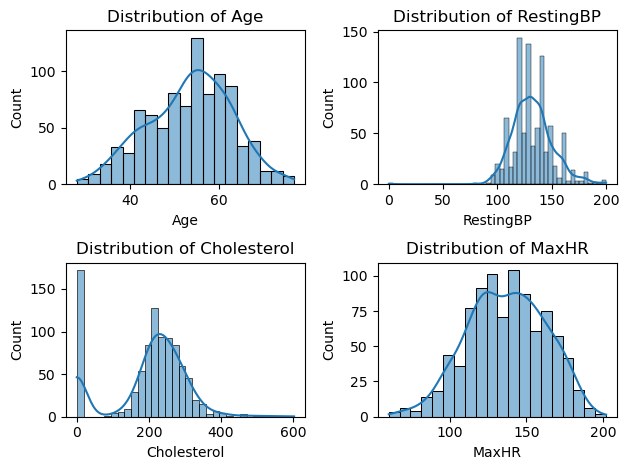

In [10]:
# Visualize numerical distributions
def plotting(var, num):
    plt.subplot(2,2, num)
    sns.histplot(df[var], kde = True)
    plt.title(f"Distribution of {var}")

plotting("Age", 1)
plotting("RestingBP", 2)
plotting("Cholesterol", 3)
plotting("MaxHR", 4)

plt.tight_layout()

In [11]:
df["Cholesterol"].value_counts()

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

## 3. Data Cleaning: Handling Hidden Missing Values
To preserve our dataset size, we will impute the zero-values in `Cholesterol` and `RestingBP` with the mean of their respective non-zero values.

In [12]:
# Impute missing values (0) in Cholesterol
ch_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()

df["Cholesterol"] = df["Cholesterol"].replace(0, ch_mean)
df["Cholesterol"] = df["Cholesterol"].round(2)

In [13]:
# Impute missing values (0) in RestingBP
resting_bp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()

df["RestingBP"] = df["RestingBP"].replace(0, resting_bp_mean)
df["RestingBP"] = df["RestingBP"].round(2)

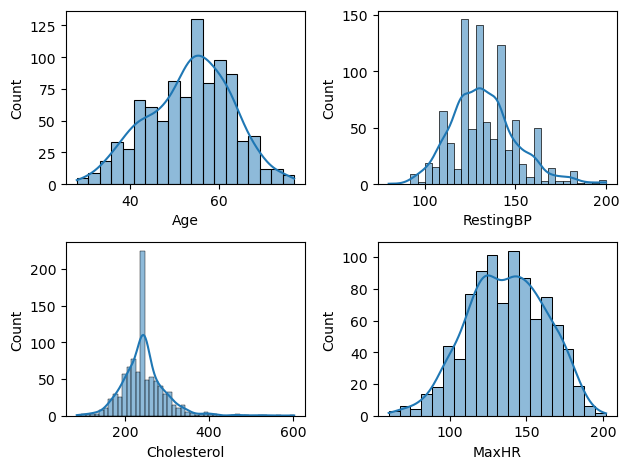

In [14]:
# Re-visualize to confirm imputation success
def plotting(var, num):
    plt.subplot(2,2, num)
    sns.histplot(df[var], kde = True)

plotting("Age", 1)
plotting("RestingBP", 2)
plotting("Cholesterol", 3)
plotting("MaxHR", 4)

plt.tight_layout()

## 4. Visualizing Relationships
We use categorical plots to understand how features like Sex, Chest Pain Type, and Fasting Blood Sugar relate to Heart Disease. Finally, a correlation heatmap helps identify linear relationships between numerical variables.

<Axes: xlabel='Sex', ylabel='count'>

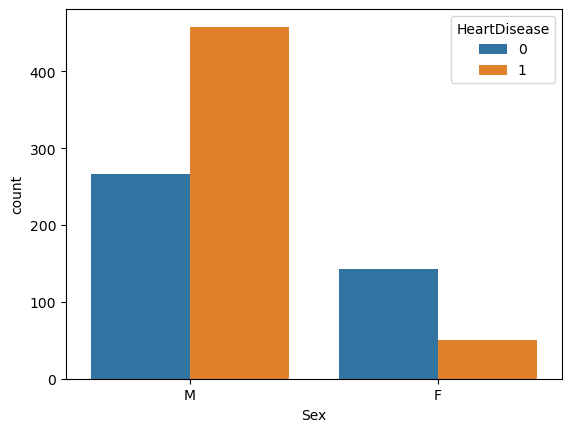

In [15]:
sns.countplot(x = df["Sex"], hue = df["HeartDisease"])

<Axes: xlabel='ChestPainType', ylabel='count'>

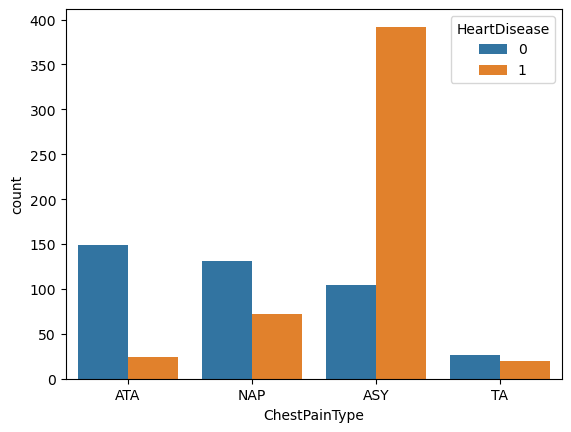

In [16]:
sns.countplot(x = df["ChestPainType"], hue = df["HeartDisease"])

<Axes: xlabel='FastingBS', ylabel='count'>

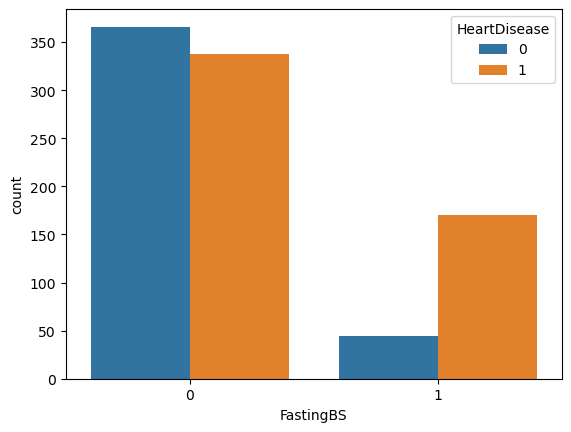

In [17]:
sns.countplot(x = df["FastingBS"], hue = df["HeartDisease"])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

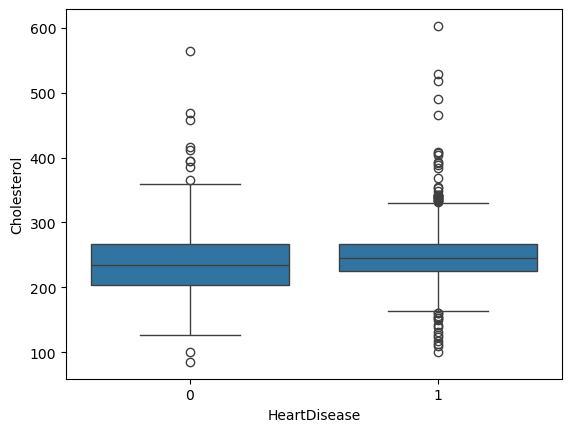

In [18]:
sns.boxplot(x = "HeartDisease", y = "Cholesterol", data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

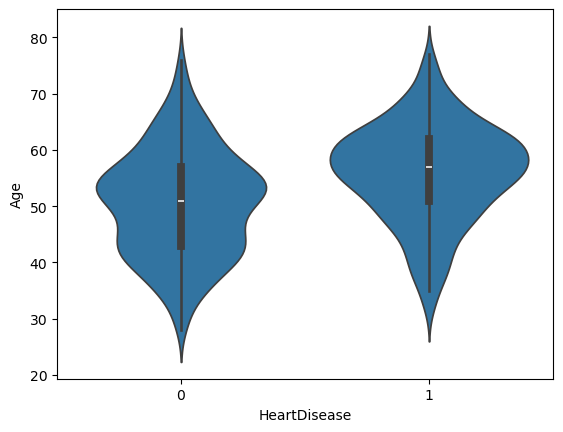

In [19]:
sns.violinplot(x = "HeartDisease", y = "Age", data=df)

<Axes: >

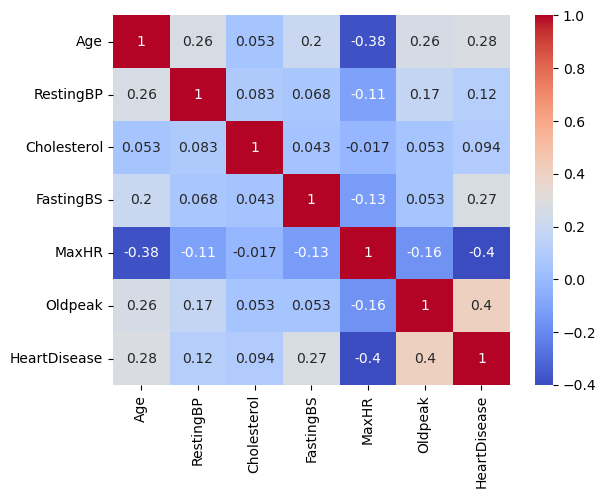

In [20]:
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = "coolwarm")

## 5. Data Preprocessing
Machine learning algorithms require numerical input. 
1. **One-Hot Encoding:** We convert categorical variables (like ChestPainType) into binary columns. We use `drop_first=True` to prevent multicollinearity.
2. **Train/Test Split:** We split the data 80/20. We use `stratify=y` to ensure the proportion of heart disease cases remains balanced between training and testing sets.
3. **Feature Scaling:** We use `StandardScaler` to normalize the data, which is critical for distance-based algorithms like KNN and SVM.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df_encoded.astype(int)

# Separate features (X) and target (y)
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Testing Data Shape: {X_test_scaled.shape}")

Training Data Shape: (734, 15)
Testing Data Shape: (184, 15)


## 6. Model Training and Evaluation
We train multiple classifiers to identify the best performer. Because this is a medical diagnosis model, we pay close attention to both **Accuracy** and the **F1-Score** (which balances Precision and Recall).

In [22]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [23]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "Naive Bayes" : GaussianNB(),
    "Decision Tree" : DecisionTreeClassifier(),
    "SVM (RBF Kernel)" : SVC(probability = True)
}

In [24]:
result = []

In [25]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        "Model" : name,
        "Accuracy" : round(acc, 4),
        "F1 Score" : round(f1, 4)
    })

In [26]:
# Display Results
result_df = pd.DataFrame(result).sort_values(by="F1 Score", ascending=False)
result_df

,Model,Accuracy,F1 Score
1,KNN,0.8859,0.8986
0,Logistic Regression,0.8750,0.8878
4,SVM (RBF Kernel),0.8641,0.8804
2,Naive Bayes,0.8696,0.8788
3,Decision Tree,0.7663,0.7839


## 7. Model Serialization for Production
The **K-Nearest Neighbors (KNN)** model yielded the highest performance. We will serialize (pickle) this model, along with the `StandardScaler` and the exact list of expected feature columns. These artifacts will be loaded by our Streamlit application (`heart_pred.py`) to process new patient data and perform real-time inference.

In [27]:
# Save the top performing model (KNN), the scaler, and the expected columns
# Filenames updated to match Streamlit script requirements exactly
joblib.dump(models["KNN"], "heart_knn_model.pkl")
joblib.dump(scaler, "heart_scaler.pkl")
joblib.dump(X.columns.tolist(), "heart_columns.pkl")

print("Pipeline artifacts saved successfully for deployment.")

Pipeline artifacts saved successfully for deployment.
